# Experimento VQC Hibryd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F


class MiDatasetCSV(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file)
        
        self.x = self.data.iloc[:, 1:-1].values
        
        self.y = self.data.iloc[:, -1].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        features = torch.tensor(self.x[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.long)

        features = features.view(1, 28, 28)

        features = features / 255.0
        
        return features, label

In [ ]:
train_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_subset_train_balanced_06.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_subset_test_balanced_06.csv')

train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader)}")
print(f"Lotes en test: {len(test_loader)}")

Lotes en train: 500
Lotes en test: 200


# Autoencoder Parametrizable

In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=4):
        super(ConvAutoencoder, self).__init__()
        self.latent_dim = latent_dim

        #ENCODER
        # Conv1: 1 canal -> 16 canales. Tamaño: 28x28 -> 14x14 (por el stride=2)
        self.enc_conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
        
        # Conv2: 16 canales -> 32 canales. Tamaño: 14x14 -> 7x7 (por el stride=2)
        self.enc_conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        
        # Aplanado: 32 canales * 7 alto * 7 ancho = 1568
        self.enc_fc = nn.Linear(32 * 7 * 7, latent_dim)
        
        #DECODER 
        # Deshacemos el aplanado: de latent_dim volvemos a 1568
        self.dec_fc = nn.Linear(latent_dim, 32 * 7 * 7)
        
        # ConvTranspose1: 32 -> 16 canales. Tamaño: 7x7 -> 14x14
        self.dec_conv1 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        # ConvTranspose2: 16 -> 1 canal. Tamaño: 14x14 -> 28x28
        self.dec_conv2 = nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = x.view(x.shape[0], -1) # Flatten
        x = self.enc_fc(x)         # Obtenemos el vector de tamaño 'latent_dim'
        return x

    def decode(self, x):
        x = self.dec_fc(x)
        x = x.view(x.shape[0], 32, 7, 7) # Volvemos a darle forma de "imagen" (canales, alto, ancho)
        x = F.relu(self.dec_conv1(x))
        x = torch.sigmoid(self.dec_conv2(x))
        return x

    def forward(self, x):
        z = self.encode(x)
        reconstructed = self.decode(z)
        return reconstructed

In [6]:
from torchview import draw_graph

model = ConvAutoencoder(latent_dim=4)

graph = draw_graph(
    model,
    input_size=(1, 1, 28, 28),
    expand_nested=True,
    graph_name="ConvAutoencoder",
    save_graph=True,
    filename="autoencoder_architecture"
)


(process:2968): Pango-WARNING **: 15:56:43.139: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim

def train_autoencoder(autoencoder, train_loader, num_epochs=20, learning_rate=1e-3):
    criterion = nn.MSELoss() 
    optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
    
    autoencoder.train()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for images, _ in train_loader: 
            
            optimizer.zero_grad()
            
            reconstructed = autoencoder(images)
            
            loss = criterion(reconstructed, images)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}")
        
    return autoencoder

#test
mi_autoencoder = ConvAutoencoder(latent_dim=4)

print("Entrenando Autoencoder clásico...")
mi_autoencoder = train_autoencoder(mi_autoencoder, train_loader_mnist01, num_epochs=25)

Entrenando Autoencoder clásico...
Epoch [1/25], Loss: 0.0227
Epoch [2/25], Loss: 0.0173
Epoch [3/25], Loss: 0.0166
Epoch [4/25], Loss: 0.0162
Epoch [5/25], Loss: 0.0159
Epoch [6/25], Loss: 0.0156
Epoch [7/25], Loss: 0.0154
Epoch [8/25], Loss: 0.0153
Epoch [9/25], Loss: 0.0151
Epoch [10/25], Loss: 0.0150
Epoch [11/25], Loss: 0.0149
Epoch [12/25], Loss: 0.0148
Epoch [13/25], Loss: 0.0148
Epoch [14/25], Loss: 0.0147
Epoch [15/25], Loss: 0.0146
Epoch [16/25], Loss: 0.0146
Epoch [17/25], Loss: 0.0145
Epoch [18/25], Loss: 0.0145
Epoch [19/25], Loss: 0.0145
Epoch [20/25], Loss: 0.0144
Epoch [21/25], Loss: 0.0144
Epoch [22/25], Loss: 0.0144
Epoch [23/25], Loss: 0.0143
Epoch [24/25], Loss: 0.0143
Epoch [25/25], Loss: 0.0143


In [ ]:

def visualizar_reconstruccion(model, dataloader):
    model.eval()
    images, _ = next(iter(dataloader))
    with torch.no_grad():
        reconstructed = model(images)
    
    # Mostrar las 5 primeras imágenes
    n = 5
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstrucción
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.title("Reconstruida")
        plt.axis('off')
    plt.show()

### Carga de los datasets

In [ ]:
#Mnist 01
train_set = MiDatasetCSV(r'..\datasets\mnist\mnist_train_01.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\mnist_test_01.csv')

train_loader_mnist01 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_mnist01 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_mnist01)}")
print(f"Lotes en test: {len(test_loader_mnist01)}")

#Mnist 36
train_set = MiDatasetCSV(r'..\datasets\mnist\mnist_train_36.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\mnist_test_36.csv')

train_loader_mnist36 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_mnist36 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_mnist36)}")
print(f"Lotes en test: {len(test_loader_mnist36)}")

#F-Mnist 01
train_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_train_01.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_test_01.csv')

train_loader_fmnist01 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_fmnist01 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_fmnist01)}")
print(f"Lotes en test: {len(test_loader_fmnist01)}")

#F-Mnist 06
train_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_train_06.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_test_06.csv')

train_loader_fmnist06 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_fmnist06 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_fmnist06)}")
print(f"Lotes en test: {len(test_loader_fmnist06)}")

In [ ]:
# Bucle entrenamiento:

datasets = [
    ("mnist01", train_loader_mnist01),
    ("mnist36", train_loader_mnist36),
    ("fmnist01", train_loader_fmnist01),
    ("fmnist06", train_loader_fmnist06)
]

n_features = [2, 4, 6, 8, 10]

for ds_name, data_loader in datasets:
    for n in n_features:
        print(f"--- Entrenando Autoencoder: {ds_name} | Dimensión latente: {n} ---")
        
        mi_autoencoder = ConvAutoencoder(latent_dim=n)

        mi_autoencoder = train_autoencoder(mi_autoencoder, data_loader, num_epochs=25)

        filename = f"../datasets/autoencoders/autoencoder_{ds_name}_lat{n}.pth"
        torch.save(mi_autoencoder.state_dict(), filename)
        
        print(f"Modelo guardado exitosamente como: {filename}\n")
        

--- Entrenando Autoencoder: mnist01 | Dimensión latente: 2 ---
Epoch [1/25], Loss: 0.0323
Epoch [2/25], Loss: 0.0263
Epoch [3/25], Loss: 0.0250
Epoch [4/25], Loss: 0.0243
Epoch [5/25], Loss: 0.0238
Epoch [6/25], Loss: 0.0234
Epoch [7/25], Loss: 0.0233
Epoch [8/25], Loss: 0.0231
Epoch [9/25], Loss: 0.0230
Epoch [10/25], Loss: 0.0230
Epoch [11/25], Loss: 0.0229
Epoch [12/25], Loss: 0.0228
Epoch [13/25], Loss: 0.0228
Epoch [14/25], Loss: 0.0227
Epoch [15/25], Loss: 0.0227
Epoch [16/25], Loss: 0.0227
Epoch [17/25], Loss: 0.0226
Epoch [18/25], Loss: 0.0226
Epoch [19/25], Loss: 0.0226
Epoch [20/25], Loss: 0.0226
Epoch [21/25], Loss: 0.0225
Epoch [22/25], Loss: 0.0225
Epoch [23/25], Loss: 0.0225
Epoch [24/25], Loss: 0.0225
Epoch [25/25], Loss: 0.0225
Modelo guardado exitosamente como: ../datasets/autoencoders/autoencoder_mnist01_lat2.pth

--- Entrenando Autoencoder: mnist01 | Dimensión latente: 4 ---
Epoch [1/25], Loss: 0.0232
Epoch [2/25], Loss: 0.0174
Epoch [3/25], Loss: 0.0166
Epoch [4/25]

## Visualización

In [ ]:
def visualizar_evolucion_latente(ds_name, dataloader, folder="../datasets/autoencoders", n_features=[2, 4, 6, 8, 10]):
    """
    Carga múltiples autoencoders de un mismo dataset y visualiza 
    cómo afecta la dimensión latente a la calidad de reconstrucción.
    """
    images_list = []
    for batch_imgs, _ in dataloader:
        for img in batch_imgs:
            images_list.append(img)
            if len(images_list) == 5:
                break
        if len(images_list) == 5:
            break
    
    images = torch.stack(images_list)

    num_filas = len(n_features) + 1
    fig, axes = plt.subplots(nrows=num_filas, ncols=5, figsize=(10, 2 * num_filas))
    fig.suptitle(f"Reconstrucciones para el dataset: {ds_name}", fontsize=16, y=1.02)

    for i in range(5):
        axes[0, i].imshow(images[i].squeeze(), cmap='gray')
        axes[0, i].set_title("Original" if i == 2 else "") # Título solo en el medio
        axes[0, i].axis('off')

    for row_idx, n in enumerate(n_features, start=1):
        # Instanciar la arquitectura vacía con la dimensión correspondiente
        model = ConvAutoencoder(latent_dim=n)
        
        # Construir la ruta del archivo
        filename = os.path.join(folder, f"autoencoder_{ds_name}_lat{n}.pth")
        
        try:
            # Cargar los pesos entrenados
            model.load_state_dict(torch.load(filename, map_location=torch.device('cpu')))
            model.eval()

            # Pasar las imágenes por el modelo sin calcular gradientes
            with torch.no_grad():
                reconstructed = model(images)

            # Dibujar la reconstrucción
            for i in range(5):
                axes[row_idx, i].imshow(reconstructed[i].squeeze(), cmap='gray')
                axes[row_idx, i].set_xticks([]) # Quitar ejes
                axes[row_idx, i].set_yticks([])
                
                # Etiqueta lateral izquierda indicando los qubits/latente
                if i == 0:
                    axes[row_idx, i].set_ylabel(f"Latente: {n}\n(Qubits: {n})", 
                                                visible=True, size='large', rotation=0, 
                                                labelpad=40, ha='center', va='center')

        except FileNotFoundError:
            print(f"⚠️ Advertencia: No se encontró el archivo {filename}")
            for i in range(5):
                axes[row_idx, i].axis('off')
                axes[row_idx, i].text(0.5, 0.5, 'Missing', ha='center', va='center')

    # Ajustar espaciados y mostrar
    plt.tight_layout()
    plt.show()

# visualizar_evolucion_latente("fmnist01", train_loader_fmnist01)
# visualizar_evolucion_latente("fmnist06", train_loader_fmnist06)
# visualizar_evolucion_latente("mnist01", train_loader_mnist01)
# visualizar_evolucion_latente("mnist36", train_loader_mnist36)

C:\Users\pablo\AppData\Local\Temp\ipykernel_34484\4288601082.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename, map_location=tor

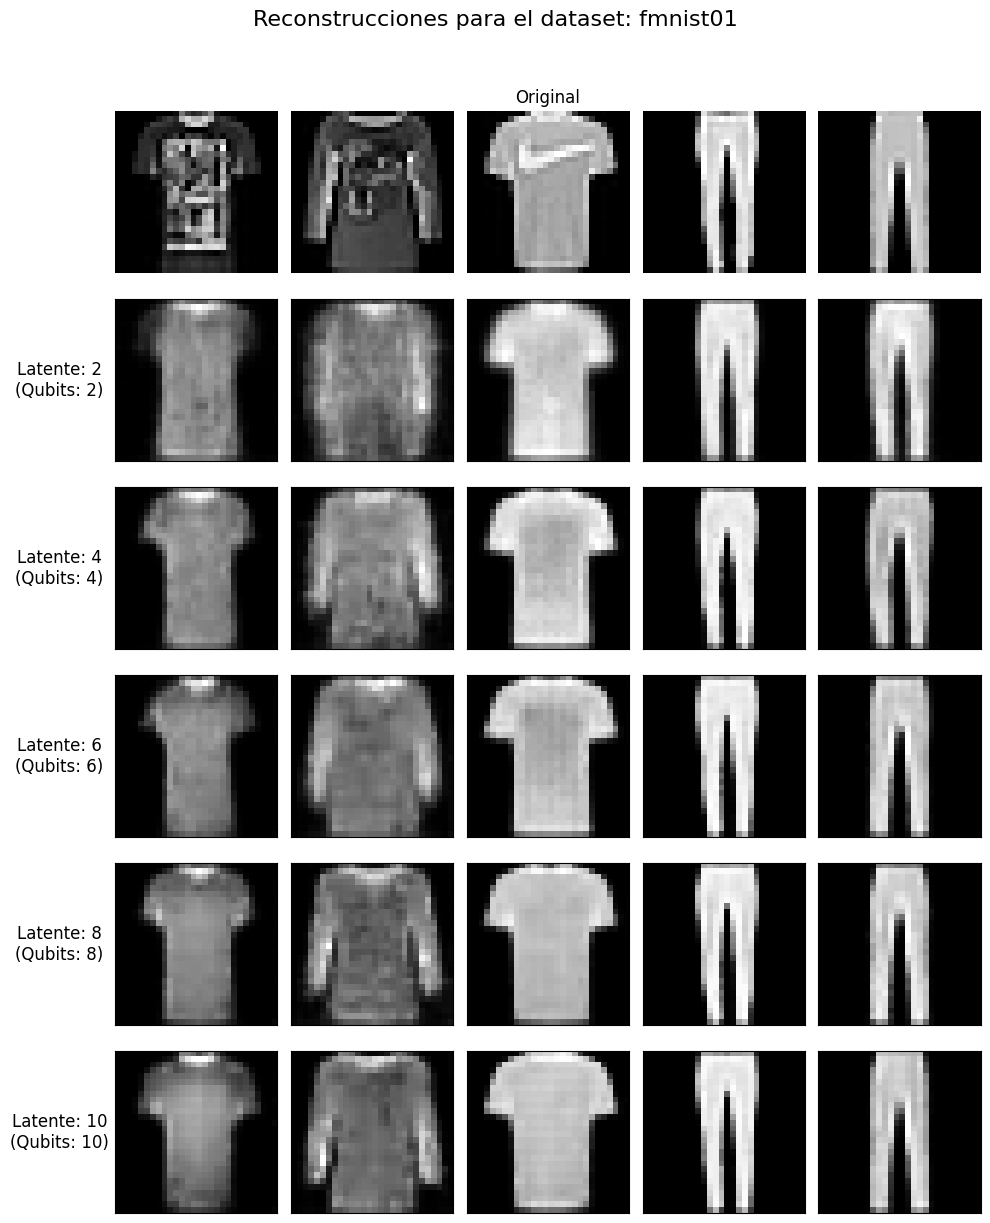

In [18]:
visualizar_evolucion_latente("fmnist01", train_loader_fmnist01)

### Preprocesando Datasets

In [4]:
#Mnist 01
train_set = MiDatasetCSV(r'..\datasets\mnist\mnist_subset_train_balanced_01.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\mnist_subset_test_balanced_01.csv')

train_loader_mnist01 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_mnist01 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_mnist01)}")
print(f"Lotes en test: {len(test_loader_mnist01)}")

#Mnist 36
train_set = MiDatasetCSV(r'..\datasets\mnist\mnist_subset_train_balanced_36.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\mnist_subset_test_balanced_36.csv')

train_loader_mnist36 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_mnist36 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_mnist36)}")
print(f"Lotes en test: {len(test_loader_mnist36)}")

#F-Mnist 01
train_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_subset_train_balanced_01.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_subset_test_balanced_01.csv')

train_loader_fmnist01 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_fmnist01 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_fmnist01)}")
print(f"Lotes en test: {len(test_loader_fmnist01)}")

#F-Mnist 06
train_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_subset_train_balanced_06.csv')
test_set = MiDatasetCSV(r'..\datasets\mnist\fmnist_subset_test_balanced_06.csv')

train_loader_fmnist06 = DataLoader(train_set, batch_size=1, shuffle=True)
test_loader_fmnist06 = DataLoader(test_set, batch_size=1, shuffle=False)

print(f"Lotes en train: {len(train_loader_fmnist06)}")
print(f"Lotes en test: {len(test_loader_fmnist06)}")

Lotes en train: 500
Lotes en test: 200
Lotes en train: 500
Lotes en test: 200
Lotes en train: 500
Lotes en test: 200
Lotes en train: 500
Lotes en test: 200


In [ ]:

def generar_y_guardar_csv_latente(model, dataloader, filename):
    model.eval() 
    latente_x = []
    labels_y = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            # 1. Extraemos SOLO usando el encoder
            z = model.encode(images)
            
            # 2. Acotamos los valores a [-1, 1]
            z = torch.tanh(z)
            
            latente_x.append(z.cpu().numpy())
            labels_y.append(labels.cpu().numpy())
            
    # Empaquetamos todo en matrices
    X = np.vstack(latente_x)
    Y = np.concatenate(labels_y)
    
    # Construimos el DataFrame
    num_features = X.shape[1]
    nombres_columnas = [f"feat_{i}" for i in range(num_features)]
    df = pd.DataFrame(X, columns=nombres_columnas)
    
    # Añadimos la etiqueta
    df['label'] = Y
    
    # Guardamos el CSV
    df.to_csv(filename, index=False)


# EJECUCIÓN DEL BUCLE 
# 1. Creamos la carpeta destino para los nuevos datasets
os.makedirs("datasets_latentes", exist_ok=True)

# 2. Agrupamos los datasets 
datasets = [
    ("mnist01", train_loader_mnist01, test_loader_mnist01),
    ("mnist36", train_loader_mnist36, test_loader_mnist36),
    ("fmnist01", train_loader_fmnist01, test_loader_fmnist01),
    ("fmnist06", train_loader_fmnist06, test_loader_fmnist06)
]

n_features = [2, 4, 6, 8, 10]

for ds_name, train_loader, test_loader in datasets:
    for n in n_features:
        print(f"Procesando {ds_name} a {n} dimensiones latentes...")
        
        # 3. Instanciamos el modelo vacío y cargamos los pesos
        modelo = ConvAutoencoder(latent_dim=n)
        ruta_modelo = f"../datasets/autoencoders/autoencoder_{ds_name}_lat{n}.pth"
        
        try:
            modelo.load_state_dict(torch.load(ruta_modelo, map_location=torch.device('cpu')))
            
            # 4. Procesamos y guardamos el conjunto de TRAIN
            csv_train = f"datasets_latentes/{ds_name}_train_lat{n}.csv"
            generar_y_guardar_csv_latente(modelo, train_loader, csv_train)
            
            # 5. Procesamos y guardamos el conjunto de TEST
            csv_test = f"datasets_latentes/{ds_name}_test_lat{n}.csv"
            generar_y_guardar_csv_latente(modelo, test_loader, csv_test)
            
        except FileNotFoundError:
            print(f"⚠️ Error: No se encontró el modelo {ruta_modelo}. Saltando...")

print("\n✅ ¡Todos los datasets han sido codificados y exportados a CSV!")

Procesando mnist01 a 2 dimensiones latentes...
Procesando mnist01 a 4 dimensiones latentes...


C:\Users\pablo\AppData\Local\Temp\ipykernel_34484\769720239.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(ruta_modelo, map_location=

Procesando mnist01 a 6 dimensiones latentes...
Procesando mnist01 a 8 dimensiones latentes...


C:\Users\pablo\AppData\Local\Temp\ipykernel_34484\769720239.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(ruta_modelo, map_location=

Procesando mnist01 a 10 dimensiones latentes...
Procesando mnist36 a 2 dimensiones latentes...


...

Procesando fmnist06 a 4 dimensiones latentes...
Procesando fmnist06 a 6 dimensiones latentes...


C:\Users\pablo\AppData\Local\Temp\ipykernel_34484\769720239.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(ruta_modelo, map_location=

Procesando fmnist06 a 8 dimensiones latentes...
Procesando fmnist06 a 10 dimensiones latentes...


C:\Users\pablo\AppData\Local\Temp\ipykernel_34484\769720239.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(ruta_modelo, map_location=


✅ ¡Todos los datasets han sido codificados y exportados a CSV!
